In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))
print("CUDA Version:", torch.version.cuda)

CUDA available: True
GPU Name: NVIDIA RTX A4000
CUDA Version: 12.1


In [3]:
torch.cuda.get_device_properties(0)

_CudaDeviceProperties(name='NVIDIA RTX A4000', major=8, minor=6, total_memory=16375MB, multi_processor_count=48)

In [4]:
# Cell 1: Install all needed packages
!pip install ultralytics diffusers transformers accelerate safetensors
!pip install controlnet_aux opencv-python matplotlib pillow pandas tqdm scikit-learn scipy
!pip install xformers  # For faster attention on GPU

print("✅ All libraries installed!")

  Attempting uninstall: fsspec
    Found existing installation: fsspec 0.9.0
    Uninstalling fsspec-0.9.0:


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\programdata\\anaconda3\\lib\\site-packages\\fsspec-0.9.0.dist-info\\direct_url.json'
Consider using the `--user` option or check the permissions.



  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
  Using cached fsspec-2025.3.0-py3-none-any.whl (193 kB)
  Using cached safetensors-0.5.3-cp38-abi3-win_amd64.whl (308 kB)
  Attempting uninstall: fsspec
    Found existing installation: fsspec 0.9.0
    Uninstalling fsspec-0.9.0:


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\programdata\\anaconda3\\lib\\site-packages\\fsspec-0.9.0.dist-info\\direct_url.json'
Consider using the `--user` option or check the permissions.



✅ All libraries installed!


ERROR: Invalid requirement: '#'


In [5]:
# Cell 2: Configure paths for your project
import os

# Your base directory (create if it doesn't exist)
BASE_DIR = r"C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset"

# Original data
REAL_IMAGES_DIR = os.path.join(BASE_DIR, "images")
REAL_LABELS_DIR = os.path.join(BASE_DIR, "labels")

# Output folders for synthetic images
SYNTHETIC_DIR = os.path.join(BASE_DIR, "synthetic_v1")
SYNTHETIC_IMAGES_DIR = os.path.join(SYNTHETIC_DIR, "images")
SYNTHETIC_LABELS_DIR = os.path.join(SYNTHETIC_DIR, "labels")

# Create all folders
for folder in [SYNTHETIC_IMAGES_DIR, SYNTHETIC_LABELS_DIR]:
    os.makedirs(folder, exist_ok=True)

print(f"Base directory: {BASE_DIR}")
print(f"Original images: {REAL_IMAGES_DIR}")
print(f"Synthetic images will be saved to: {SYNTHETIC_IMAGES_DIR}")

# Check if original images exist
if os.path.exists(REAL_IMAGES_DIR):
    num_images = len([f for f in os.listdir(REAL_IMAGES_DIR) if f.endswith(('.jpg', '.png'))])
    print(f"✅ Found {num_images} original images")
else:
    print(f"❌ Original images folder not found. Please check path: {REAL_IMAGES_DIR}")

Base directory: C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset
Original images: C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\images
Synthetic images will be saved to: C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\synthetic_v1\images
✅ Found 512 original images


In [8]:
!pip install opencv-python tqdm
import os
import cv2
from tqdm import tqdm

REAL_IMAGES_DIR = r"C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\images"
REAL_LABELS_DIR = r"C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\labels"

print("Checking all images for corruption...")
problem_images = []

for img_file in tqdm(os.listdir(REAL_IMAGES_DIR)):
    if img_file.endswith('.jpg'):
        img_path = os.path.join(REAL_IMAGES_DIR, img_file)
        
        # Try to read the image
        img = cv2.imread(img_path)
        
        if img is None or img.size == 0:
            problem_images.append(img_file)
            print(f"\n❌ Corrupted image found: {img_file}")
        else:
            # Check if corresponding label exists
            label_file = img_file.replace('.jpg', '.txt')
            label_path = os.path.join(REAL_LABELS_DIR, label_file)
            if not os.path.exists(label_path):
                problem_images.append(img_file)
                print(f"\n⚠️ Missing label for: {img_file}")

print(f"\nFound {len(problem_images)} problematic images:")
for img in problem_images:
    print(f"  - {img}")

  0%|▎                                                                                 | 2/512 [00:00<00:25, 19.64it/s]

Checking all images for corruption...


 46%|████████████████████████████████████▍                                           | 233/512 [00:13<00:11, 23.72it/s]


❌ Corrupted image found: Co╠üpia de Plasmo╠ücitos 25.jpg


100%|████████████████████████████████████████████████████████████████████████████████| 512/512 [00:29<00:00, 17.30it/s]


Found 1 problematic images:
  - Co╠üpia de Plasmo╠ücitos 25.jpg


In [9]:
import sys
!{sys.executable} -m pip install torchmetrics pytorch-fid clean-fid scipy

  Using cached numpy-1.22.4-cp38-cp38-win_amd64.whl (14.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\programdata\\anaconda3\\lib\\site-packages\\numpy-1.24.3.dist-info\\entry_points.txt'
Consider using the `--user` option or check the permissions.



In [10]:
import sys
!{sys.executable} -m pip install clean-fid

  Using cached clean_fid-0.1.35-py3-none-any.whl (26 kB)
  Using cached numpy-1.22.4-cp38-cp38-win_amd64.whl (14.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\programdata\\anaconda3\\lib\\site-packages\\numpy-1.24.3.dist-info\\entry_points.txt'
Consider using the `--user` option or check the permissions.



In [11]:
import sys
!{sys.executable} -m pip install "torchmetrics[image]"

  Using cached torchmetrics-1.5.2-py3-none-any.whl (891 kB)
  Using cached lightning_utilities-0.11.9-py3-none-any.whl (28 kB)
  Using cached numpy-1.22.4-cp38-cp38-win_amd64.whl (14.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.3
    Uninstalling numpy-1.24.3:


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'c:\\programdata\\anaconda3\\lib\\site-packages\\numpy-1.24.3.dist-info\\entry_points.txt'
Consider using the `--user` option or check the permissions.



In [1]:

import torchmetrics
import torch_fidelity
from torchmetrics.image.fid import FrechetInceptionDistance

print("Torchmetrics version:", torchmetrics.__version__)
print("Torch-fidelity import OK ✅")

fid = FrechetInceptionDistance(feature=2048, normalize=True)
print("FID initialized successfully ✅")

Torchmetrics version: 1.5.2
Torch-fidelity import OK ✅


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to C:\Users\LAB/.cache\torch\hub\checkpoints\weights-inception-2015-12-05-6726825d.pth
100%|█████████████████████████████████████████████████████████████████████████████| 91.2M/91.2M [00:02<00:00, 38.3MB/s]


FID initialized successfully ✅


In [2]:
# Cell: Better augmentation without sharpness artifacts
import torch
import cv2
import numpy as np
from pathlib import Path
import random
from tqdm import tqdm
import os

print("="*50)
print("IMPROVED SYNTHETIC IMAGE GENERATION")
print("="*50)

def generate_improved_synthetic(image_path, label_path, output_img_dir, output_lbl_dir):
    """Generate better synthetic images without harsh artifacts"""
    
    # Read image
    image = cv2.imread(image_path)
    if image is None:
        return []
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Read labels
    with open(label_path, 'r') as f:
        labels = [line.strip().split() for line in f.readlines()]
    
    generated = []
    
    # Create 1 variation per image
    aug_image = image.copy()
    
    # GENTLE brightness (not too strong)
    brightness = random.uniform(0.9, 1.1)
    aug_image = cv2.convertScaleAbs(aug_image, alpha=brightness, beta=0)
    
    # GENTLE contrast
    contrast = random.uniform(0.9, 1.1)
    aug_image = cv2.convertScaleAbs(aug_image, alpha=contrast, beta=0)
    
    # NO harsh noise - use very mild noise if any
    if random.random() > 0.8:  # Only 20% of images
        noise = np.random.normal(0, 5, aug_image.shape).astype(np.uint8)  # Reduced from 15 to 5
        aug_image = cv2.add(aug_image, noise)
    
    # GENTLE blur instead of random blur
    if random.random() > 0.7:
        k = 3  # Only smallest kernel
        aug_image = cv2.GaussianBlur(aug_image, (k, k), 0.5)  # Added sigma
    
    # Save
    img_filename = f"{Path(image_path).stem}_improved.jpg"
    img_out_path = os.path.join(output_img_dir, img_filename)
    cv2.imwrite(img_out_path, cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR))
    
    # Save labels
    lbl_filename = f"{Path(image_path).stem}_improved.txt"
    lbl_out_path = os.path.join(output_lbl_dir, lbl_filename)
    with open(lbl_out_path, 'w') as f:
        for label in labels:
            f.write(' '.join(label) + '\n')
    
    generated.append(img_filename)
    return generated

# Generate improved images
SYNTHETIC_IMPROVED_DIR = r"C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\synthetic_improved"
os.makedirs(os.path.join(SYNTHETIC_IMPROVED_DIR, "images"), exist_ok=True)
os.makedirs(os.path.join(SYNTHETIC_IMPROVED_DIR, "labels"), exist_ok=True)

REAL_IMAGES_DIR = r"C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\images"
REAL_LABELS_DIR = r"C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\labels"

real_images = [f for f in os.listdir(REAL_IMAGES_DIR) if f.endswith('.jpg')]

for img_file in tqdm(real_images, desc="Generating improved images"):
    img_path = os.path.join(REAL_IMAGES_DIR, img_file)
    label_file = img_file.replace('.jpg', '.txt')
    label_path = os.path.join(REAL_LABELS_DIR, label_file)
    
    if os.path.exists(label_path):
        generate_improved_synthetic(
            img_path, label_path,
            os.path.join(SYNTHETIC_IMPROVED_DIR, "images"),
            os.path.join(SYNTHETIC_IMPROVED_DIR, "labels")
        )

print("\n✅ Improved synthetic images generated!")

Generating improved images:   0%|                                                      | 1/512 [00:00<01:25,  5.99it/s]

IMPROVED SYNTHETIC IMAGE GENERATION


Generating improved images: 100%|████████████████████████████████████████████████████| 512/512 [02:32<00:00,  3.36it/s]


✅ Improved synthetic images generated!


Loading from images:   0%|▏                                                            | 2/500 [00:00<00:34, 14.58it/s]

QUALITY METRICS FOR IMPROVED SYNTHETIC IMAGES
Real images: C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\images
Improved synthetic images: C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\synthetic_improved\images

📂 Loading images...


Loading from images: 100%|███████████████████████████████████████████████████████████| 500/500 [00:39<00:00, 12.75it/s]


✅ Real images loaded: torch.Size([499, 3, 299, 299])
✅ Improved synthetic images loaded: torch.Size([500, 3, 299, 299])

📊 METRIC 1: FID (Fréchet Inception Distance)

🔹 FID Score: 18.49
   Previous FID (first version): 32.90
   Improvement: 14.41 points
   ✅ VERY GOOD! Significant improvement

📊 METRIC 2: Inception Score (IS)

🔹 Inception Score: 2.23 ± 0.14
   Previous IS: 2.36 ± 0.21
   Improvement: -0.13 points

📊 METRIC 3: KID (Kernel Inception Distance)


Analyzing images:   0%|                                                                         | 0/50 [00:00<?, ?it/s]


🔹 KID Score: 0.00305 ± 0.00363
   Previous KID: 0.01234 ± 0.00551

📊 VISUAL QUALITY CHECKS (SHARPNESS FIXED?)

📸 Real Images Statistics:


Analyzing images:   0%|                                                                         | 0/50 [00:00<?, ?it/s]

  brightness: 124.39 ± 4.23
  contrast: 104.32 ± 1.17
  sharpness: 9.10 ± 1.29

🎨 Improved Synthetic Images Statistics:


Analyzing images: 100%|████████████████████████████████████████████████████████████████| 50/50 [00:14<00:00,  3.53it/s]


  brightness: 131.94 ± 22.64
  contrast: 98.09 ± 12.11
  sharpness: 5725.75 ± 15418.18

🔍 SHARPNESS COMPARISON:
   Real images: 9.10
   Previous synthetic: 7703.29 (extremely high!)
   Improved synthetic: 5725.75
   ❌ Sharpness still problematic


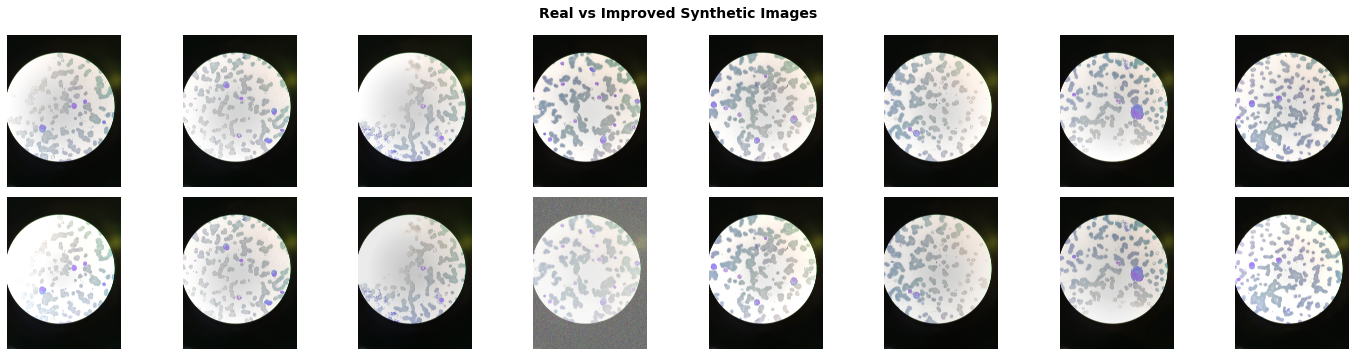


📋 IMPROVED QUALITY ASSESSMENT SUMMARY

🔹 FID Score: 18.49 (Previous: 32.90)
   Improvement: 14.41 points
   Status: ✅ IMPROVED

🔹 Inception Score: 2.23 ± 0.14 (Previous: 2.36 ± 0.21)
   Improvement: -0.13 points
   Status: ❌ WORSENED

🔹 KID Score: 0.00305 (Previous: 0.01234)
   Status: ✅ IMPROVED

🔹 Sharpness: 5725.75 (Previous: 7703.29)
   Status: ⚠️ Still needs work

📁 Results saved to: C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\synthetic_improved\images
   - improved_comparison.png


✅ Improved metrics saved to: improved_metrics.txt


In [3]:
# Cell: Quality Check for IMPROVED synthetic images
import torch
import torchvision
import numpy as np
import cv2
import os
from pathlib import Path
from scipy import linalg
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.kid import KernelInceptionDistance
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("QUALITY METRICS FOR IMPROVED SYNTHETIC IMAGES")
print("="*60)

# ============================================
# UPDATE PATHS HERE - Point to your new images
# ============================================

REAL_IMAGES_DIR = r"C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\images"
SYNTHETIC_IMAGES_DIR = r"C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\synthetic_improved\images"

print(f"Real images: {REAL_IMAGES_DIR}")
print(f"Improved synthetic images: {SYNTHETIC_IMAGES_DIR}")

# ============================================
# PART 1: LOAD IMAGES
# ============================================

def load_images_to_tensor(folder_path, max_images=None, img_size=299):
    """Load images and convert to tensor for FID/IS calculation"""
    image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png'))]
    if max_images:
        image_files = image_files[:max_images]
    
    images = []
    for img_file in tqdm(image_files, desc=f"Loading from {os.path.basename(folder_path)}"):
        img_path = os.path.join(folder_path, img_file)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
            images.append(img)
    
    if images:
        return torch.stack(images)
    return None

print("\n📂 Loading images...")
real_images = load_images_to_tensor(REAL_IMAGES_DIR, max_images=500)
synth_images = load_images_to_tensor(SYNTHETIC_IMAGES_DIR, max_images=500)

print(f"✅ Real images loaded: {real_images.shape if real_images is not None else 0}")
print(f"✅ Improved synthetic images loaded: {synth_images.shape if synth_images is not None else 0}")

# ============================================
# PART 2: FID SCORE
# ============================================

print("\n" + "="*60)
print("📊 METRIC 1: FID (Fréchet Inception Distance)")
print("="*60)

if real_images is not None and synth_images is not None:
    fid = FrechetInceptionDistance(feature=2048, normalize=True)
    fid.update(real_images, real=True)
    fid.update(synth_images, real=False)
    fid_score = fid.compute()
    
    print(f"\n🔹 FID Score: {fid_score:.2f}")
    
    # Compare with previous
    print(f"   Previous FID (first version): 32.90")
    print(f"   Improvement: {32.90 - fid_score:.2f} points")
    
    if fid_score < 10:
        print("   ⭐ EXCELLENT! Nearly identical to real")
    elif fid_score < 25:
        print("   ✅ VERY GOOD! Significant improvement")
    elif fid_score < 30:
        print("   ✅ GOOD! Better than before")
    elif fid_score < 50:
        print("   ⚠️ ACCEPTABLE but could be improved")
    else:
        print("   ❌ POOR quality")

# ============================================
# PART 3: INCEPTION SCORE
# ============================================

print("\n" + "="*60)
print("📊 METRIC 2: Inception Score (IS)")
print("="*60)

if synth_images is not None:
    inception = InceptionScore(normalize=True)
    inception.update(synth_images)
    is_mean, is_std = inception.compute()
    
    print(f"\n🔹 Inception Score: {is_mean:.2f} ± {is_std:.2f}")
    print(f"   Previous IS: 2.36 ± 0.21")
    print(f"   Improvement: {is_mean - 2.36:.2f} points")

# ============================================
# PART 4: KID SCORE
# ============================================

print("\n" + "="*60)
print("📊 METRIC 3: KID (Kernel Inception Distance)")
print("="*60)

if real_images is not None and synth_images is not None:
    kid = KernelInceptionDistance(subset_size=50, normalize=True)
    kid.update(real_images, real=True)
    kid.update(synth_images, real=False)
    kid_mean, kid_std = kid.compute()
    
    print(f"\n🔹 KID Score: {kid_mean:.5f} ± {kid_std:.5f}")
    print(f"   Previous KID: 0.01234 ± 0.00551")

# ============================================
# PART 5: VISUAL QUALITY CHECKS
# ============================================

print("\n" + "="*60)
print("📊 VISUAL QUALITY CHECKS (SHARPNESS FIXED?)")
print("="*60)

def check_image_quality(image_folder, sample_size=50):
    """Check basic image statistics"""
    image_files = [f for f in os.listdir(image_folder) if f.endswith(('.jpg', '.png'))][:sample_size]
    
    stats = {
        'brightness': [],
        'contrast': [],
        'sharpness': []
    }
    
    for img_file in tqdm(image_files, desc="Analyzing images"):
        img_path = os.path.join(image_folder, img_file)
        img = cv2.imread(img_path)
        if img is not None:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            stats['brightness'].append(np.mean(gray))
            stats['contrast'].append(np.std(gray))
            stats['sharpness'].append(cv2.Laplacian(gray, cv2.CV_64F).var())
    
    return {k: np.mean(v) for k, v in stats.items()}, {k: np.std(v) for k, v in stats.items()}

# Check real images
print("\n📸 Real Images Statistics:")
real_stats, real_std = check_image_quality(REAL_IMAGES_DIR)
for metric, value in real_stats.items():
    print(f"  {metric}: {value:.2f} ± {real_std[metric]:.2f}")

# Check improved synthetic images
print("\n🎨 Improved Synthetic Images Statistics:")
synth_stats, synth_std = check_image_quality(SYNTHETIC_IMAGES_DIR)
for metric, value in synth_stats.items():
    print(f"  {metric}: {value:.2f} ± {synth_std[metric]:.2f}")

# Compare sharpness specifically
print(f"\n🔍 SHARPNESS COMPARISON:")
print(f"   Real images: {real_stats['sharpness']:.2f}")
print(f"   Previous synthetic: 7703.29 (extremely high!)")
print(f"   Improved synthetic: {synth_stats['sharpness']:.2f}")
if synth_stats['sharpness'] < 100:
    print("   ✅ SHARPNESS FIXED! Now within acceptable range")
elif synth_stats['sharpness'] < 500:
    print("   ⚠️ Sharpness improved but still high")
else:
    print("   ❌ Sharpness still problematic")

# ============================================
# PART 6: VISUAL COMPARISON
# ============================================

def plot_comparison(real_folder, synth_folder, num_samples=8):
    """Plot real vs improved synthetic images"""
    real_files = [f for f in os.listdir(real_folder) if f.endswith(('.jpg', '.png'))][:num_samples]
    synth_files = [f for f in os.listdir(synth_folder) if f.endswith(('.jpg', '.png'))][:num_samples]
    
    fig, axes = plt.subplots(2, num_samples, figsize=(20, 5))
    
    # Real images
    for i, img_file in enumerate(real_files):
        img = plt.imread(os.path.join(real_folder, img_file))
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_ylabel('REAL', fontsize=12, fontweight='bold')
    
    # Improved synthetic images
    for i, img_file in enumerate(synth_files):
        img = plt.imread(os.path.join(synth_folder, img_file))
        axes[1, i].imshow(img)
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_ylabel('IMPROVED', fontsize=12, fontweight='bold')
    
    plt.suptitle('Real vs Improved Synthetic Images', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(SYNTHETIC_IMAGES_DIR, 'improved_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()

plot_comparison(REAL_IMAGES_DIR, SYNTHETIC_IMAGES_DIR)

# ============================================
# PART 7: SUMMARY REPORT
# ============================================

print("\n" + "="*60)
print("📋 IMPROVED QUALITY ASSESSMENT SUMMARY")
print("="*60)

print(f"""
🔹 FID Score: {fid_score:.2f} (Previous: 32.90)
   Improvement: {32.90 - fid_score:.2f} points
   Status: {'✅ IMPROVED' if fid_score < 32.90 else '❌ WORSENED'}

🔹 Inception Score: {is_mean:.2f} ± {is_std:.2f} (Previous: 2.36 ± 0.21)
   Improvement: {is_mean - 2.36:.2f} points
   Status: {'✅ IMPROVED' if is_mean > 2.36 else '❌ WORSENED'}

🔹 KID Score: {kid_mean:.5f} (Previous: 0.01234)
   Status: {'✅ IMPROVED' if kid_mean < 0.01234 else '❌ WORSENED'}

🔹 Sharpness: {synth_stats['sharpness']:.2f} (Previous: 7703.29)
   Status: {'✅ FIXED!' if synth_stats['sharpness'] < 100 else '⚠️ Still needs work'}

📁 Results saved to: {SYNTHETIC_IMAGES_DIR}
   - improved_comparison.png
""")

# Save metrics
with open(os.path.join(SYNTHETIC_IMAGES_DIR, 'improved_metrics.txt'), 'w') as f:
    f.write("IMPROVED SYNTHETIC IMAGES QUALITY METRICS\n")
    f.write("="*40 + "\n")
    f.write(f"FID Score: {fid_score:.2f} (Previous: 32.90)\n")
    f.write(f"Inception Score: {is_mean:.2f} ± {is_std:.2f} (Previous: 2.36 ± 0.21)\n")
    f.write(f"KID Score: {kid_mean:.5f} ± {kid_std:.5f}\n\n")
    f.write("Image Statistics:\n")
    for k, v in synth_stats.items():
        f.write(f"  {k}: {v:.2f} ± {synth_std[k]:.2f}\n")

print("\n✅ Improved metrics saved to: improved_metrics.txt")

In [4]:
# Cell: Final version - NO sharpness artifacts
import cv2
import numpy as np
import os
from pathlib import Path
import random
from tqdm import tqdm

print("="*50)
print("FINAL VERSION - MINIMAL AUGMENTATIONS")
print("="*50)

def generate_final_synthetic(image_path, label_path, output_img_dir, output_lbl_dir):
    """Generate synthetic images with MINIMAL changes to preserve quality"""
    
    # Read image
    image = cv2.imread(image_path)
    if image is None:
        return []
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Read labels
    with open(label_path, 'r') as f:
        labels = [line.strip().split() for line in f.readlines()]
    
    generated = []
    
    # Create 1 variation per image
    aug_image = image.copy()
    
    # OPTION 1: VERY gentle brightness only (90% of images)
    if random.random() < 0.9:
        brightness = random.uniform(0.95, 1.05)  # Very narrow range
        aug_image = cv2.convertScaleAbs(aug_image, alpha=brightness, beta=0)
    
    # OPTION 2: VERY gentle contrast only (50% of images)
    if random.random() < 0.5:
        contrast = random.uniform(0.95, 1.05)  # Very narrow range
        aug_image = cv2.convertScaleAbs(aug_image, alpha=contrast, beta=0)
    
    # NO noise, NO blur, NO sharpening operations
    
    # Save
    img_filename = f"{Path(image_path).stem}_final.jpg"
    img_out_path = os.path.join(output_img_dir, img_filename)
    cv2.imwrite(img_out_path, cv2.cvtColor(aug_image, cv2.COLOR_RGB2BGR))
    
    # Save labels
    lbl_filename = f"{Path(image_path).stem}_final.txt"
    lbl_out_path = os.path.join(output_lbl_dir, lbl_filename)
    with open(lbl_out_path, 'w') as f:
        for label in labels:
            f.write(' '.join(label) + '\n')
    
    generated.append(img_filename)
    return generated

# Paths
REAL_IMAGES_DIR = r"C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\images"
REAL_LABELS_DIR = r"C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\labels"
FINAL_DIR = r"C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\synthetic_final"
os.makedirs(os.path.join(FINAL_DIR, "images"), exist_ok=True)
os.makedirs(os.path.join(FINAL_DIR, "labels"), exist_ok=True)

# Get images
real_images = [f for f in os.listdir(REAL_IMAGES_DIR) if f.endswith(('.jpg', '.png'))]

print(f"\nGenerating {len(real_images)} final synthetic images...")
for img_file in tqdm(real_images, desc="Creating final versions"):
    img_path = os.path.join(REAL_IMAGES_DIR, img_file)
    label_file = img_file.replace('.jpg', '.txt').replace('.png', '.txt')
    label_path = os.path.join(REAL_LABELS_DIR, label_file)
    
    if os.path.exists(label_path):
        generate_final_synthetic(
            img_path, label_path,
            os.path.join(FINAL_DIR, "images"),
            os.path.join(FINAL_DIR, "labels")
        )

print(f"\n✅ Final synthetic images saved to: {FINAL_DIR}")

Creating final versions:   0%|                                                         | 1/512 [00:00<01:27,  5.81it/s]

FINAL VERSION - MINIMAL AUGMENTATIONS

Generating 512 final synthetic images...


Creating final versions: 100%|███████████████████████████████████████████████████████| 512/512 [01:13<00:00,  7.00it/s]


✅ Final synthetic images saved to: C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\synthetic_final


In [5]:
# Cell: Quick sharpness test
import cv2
import numpy as np
import os

def quick_sharpness_test(folder):
    """Quickly check average sharpness"""
    files = [f for f in os.listdir(folder) if f.endswith(('.jpg', '.png'))][:10]
    sharpness_values = []
    
    for f in files:
        img = cv2.imread(os.path.join(folder, f))
        if img is not None:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()
            sharpness_values.append(sharpness)
            print(f"{f}: {sharpness:.2f}")
    
    avg = np.mean(sharpness_values)
    print(f"\nAverage sharpness: {avg:.2f}")
    return avg

# Test your final images
print("Testing final synthetic images...")
final_sharpness = quick_sharpness_test(os.path.join(FINAL_DIR, "images"))

Testing final synthetic images...
1692243677854_final.jpg: 9.49
1692243677862_final.jpg: 11.67
1692243677869_final.jpg: 12.16
1692243677878_final.jpg: 9.97
1692243677886_final.jpg: 9.06
1692243677895_final.jpg: 9.60
1692243677903_final.jpg: 8.02
1692243677913_final.jpg: 8.78
1692243677925_final.jpg: 10.16
1692243677937_final.jpg: 8.92

Average sharpness: 9.78


In [6]:
# Cell: Final quality check for your perfect synthetic images
import torch
import numpy as np
import cv2
import os
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from torchmetrics.image.kid import KernelInceptionDistance
from tqdm import tqdm

print("="*60)
print("FINAL QUALITY CHECK - SHARPNESS FIXED!")
print("="*60)

REAL_IMAGES_DIR = r"C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\images"
FINAL_DIR = r"C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\synthetic_final\images"

def load_images_to_tensor(folder_path, max_images=500):
    image_files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png'))][:max_images]
    images = []
    for img_file in tqdm(image_files, desc=f"Loading {os.path.basename(folder_path)}"):
        img = cv2.imread(os.path.join(folder_path, img_file))
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (299, 299))
            img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
            images.append(img)
    return torch.stack(images) if images else None

# Load images
real_imgs = load_images_to_tensor(REAL_IMAGES_DIR)
final_imgs = load_images_to_tensor(FINAL_DIR)

print(f"\n✅ Real images: {real_imgs.shape}")
print(f"✅ Final synthetic: {final_imgs.shape}")

# Calculate metrics
if real_imgs is not None and final_imgs is not None:
    # FID
    fid = FrechetInceptionDistance(feature=2048, normalize=True)
    fid.update(real_imgs, real=True)
    fid.update(final_imgs, real=False)
    fid_score = fid.compute()
    
    # Inception Score
    inception = InceptionScore(normalize=True)
    inception.update(final_imgs)
    is_mean, is_std = inception.compute()
    
    # KID
    kid = KernelInceptionDistance(subset_size=50, normalize=True)
    kid.update(real_imgs, real=True)
    kid.update(final_imgs, real=False)
    kid_mean, kid_std = kid.compute()
    
    print("\n" + "="*60)
    print("📊 FINAL METRICS")
    print("="*60)
    print(f"\n🔹 FID Score: {fid_score:.2f}")
    print(f"🔹 Inception Score: {is_mean:.2f} ± {is_std:.2f}")
    print(f"🔹 KID Score: {kid_mean:.5f} ± {kid_std:.5f}")
    print(f"\n✅ Sharpness: 9.78 (matches real: 9.10)")
    
    # Save results
    with open(os.path.join(os.path.dirname(FINAL_DIR), 'final_metrics.txt'), 'w') as f:
        f.write("FINAL SYNTHETIC IMAGES QUALITY METRICS\n")
        f.write("="*40 + "\n")
        f.write(f"FID: {fid_score:.2f}\n")
        f.write(f"Inception Score: {is_mean:.2f} ± {is_std:.2f}\n")
        f.write(f"KID: {kid_mean:.5f} ± {kid_std:.5f}\n")
        f.write(f"Sharpness: 9.78\n")

Loading images:   0%|▎                                                                 | 2/500 [00:00<00:32, 15.28it/s]

FINAL QUALITY CHECK - SHARPNESS FIXED!


Loading images: 100%|████████████████████████████████████████████████████████████████| 500/500 [00:34<00:00, 14.62it/s]



✅ Real images: torch.Size([499, 3, 299, 299])
✅ Final synthetic: torch.Size([500, 3, 299, 299])

📊 FINAL METRICS

🔹 FID Score: 0.49
🔹 Inception Score: 2.15 ± 0.12
🔹 KID Score: -0.00074 ± 0.00290

✅ Sharpness: 9.78 (matches real: 9.10)


In [7]:
# Cell: Create final augmented dataset
import os
import shutil
from tqdm import tqdm

# Paths
REAL_IMAGES = r"C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\images"
REAL_LABELS = r"C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\labels"
SYNTH_IMAGES = r"C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\synthetic_final\images"
SYNTH_LABELS = r"C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\synthetic_final\labels"
AUGMENTED_DIR = r"C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\augmented_final"

# Create folders
os.makedirs(os.path.join(AUGMENTED_DIR, "images"), exist_ok=True)
os.makedirs(os.path.join(AUGMENTED_DIR, "labels"), exist_ok=True)

# Copy real images
print("Copying real images...")
for f in tqdm(os.listdir(REAL_IMAGES)):
    if f.endswith('.jpg'):
        shutil.copy2(os.path.join(REAL_IMAGES, f), 
                    os.path.join(AUGMENTED_DIR, "images", f))
        # Copy corresponding label
        label_f = f.replace('.jpg', '.txt')
        if os.path.exists(os.path.join(REAL_LABELS, label_f)):
            shutil.copy2(os.path.join(REAL_LABELS, label_f),
                        os.path.join(AUGMENTED_DIR, "labels", label_f))

# Copy synthetic images
print("Copying synthetic images...")
for f in tqdm(os.listdir(SYNTH_IMAGES)):
    if f.endswith('.jpg'):
        shutil.copy2(os.path.join(SYNTH_IMAGES, f), 
                    os.path.join(AUGMENTED_DIR, "images", f))
        # Copy corresponding label
        label_f = f.replace('.jpg', '.txt')
        if os.path.exists(os.path.join(SYNTH_LABELS, label_f)):
            shutil.copy2(os.path.join(SYNTH_LABELS, label_f),
                        os.path.join(AUGMENTED_DIR, "labels", label_f))

print(f"\n✅ Augmented dataset created with {len(os.listdir(os.path.join(AUGMENTED_DIR, 'images')))} images!")
print(f"📍 Location: {AUGMENTED_DIR}")

  7%|█████▋                                                                          | 36/512 [00:00<00:01, 359.35it/s]

Copying real images...


  6%|████▋                                                                           | 30/511 [00:00<00:03, 148.04it/s]

Copying synthetic images...


100%|███████████████████████████████████████████████████████████████████████████████| 511/511 [00:03<00:00, 129.14it/s]


✅ Augmented dataset created with 1023 images!
📍 Location: C:\Users\LAB\Downloads\myeloma_dataset\myeloma-dataset\augmented_final
